In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path("/home/harielpadillasanchez/Documentos/TT/TT2")

QUAL_SELF_REFINE_PATH = (
    PROJECT_ROOT 
    / "data" 
    / "cualitativa" 
    / "Evaluación cualitativa_with_self_refine.xlsx"
)

print("Archivo:", QUAL_SELF_REFINE_PATH)
print("Existe:", QUAL_SELF_REFINE_PATH.exists())

if not QUAL_SELF_REFINE_PATH.exists():
    raise FileNotFoundError(QUAL_SELF_REFINE_PATH)

# Leer estructura general del Excel
xls = pd.ExcelFile(QUAL_SELF_REFINE_PATH)

print("\nHojas disponibles:")
for i, sheet in enumerate(xls.sheet_names, start=1):
    print(f"{i}. {sheet}")

print("\n" + "="*100)
print("Exploración por hoja")
print("="*100)

sheets_info = []

for sheet in xls.sheet_names:
    print("\n" + "-"*100)
    print(f"HOJA: {sheet}")
    print("-"*100)
    
    df_sheet = pd.read_excel(QUAL_SELF_REFINE_PATH, sheet_name=sheet)
    
    print("Shape:", df_sheet.shape)
    print("Columnas:")
    print(df_sheet.columns.tolist())
    
    sheets_info.append({
        "sheet_name": sheet,
        "n_rows": df_sheet.shape[0],
        "n_cols": df_sheet.shape[1],
        "columns": df_sheet.columns.tolist(),
    })
    
    display(df_sheet.head(8))
    
    # Conteo de columnas con datos no nulos
    non_null_counts = df_sheet.notna().sum().reset_index()
    non_null_counts.columns = ["columna", "valores_no_nulos"]
    display(non_null_counts)

sheets_info_df = pd.DataFrame(sheets_info)

display(sheets_info_df[["sheet_name", "n_rows", "n_cols"]])

Archivo: /home/harielpadillasanchez/Documentos/TT/TT2/data/cualitativa/Evaluación cualitativa_with_self_refine.xlsx
Existe: True

Hojas disponibles:
1. Rúbrica
2. Textos simplificados
3. Evaluación cualitativa
4. Textos simplificados Fine-tunin
5. Evaluación cualitativa fine tun
6. Textos simplificados Self-refin
7. Evaluación cualitativa Self-ref

Exploración por hoja

----------------------------------------------------------------------------------------------------
HOJA: Rúbrica
----------------------------------------------------------------------------------------------------
Shape: (8, 6)
Columnas:
['Criterio', 'Peso', 'Qué se evalúa', 'Nivel 5', 'Nivel 3', 'Nivel 1']


,Criterio,Peso,Qué se evalúa,Nivel 5,Nivel 3,Nivel 1
0,Fidelidad semántica,0.25,"El texto simplificado conserva las ideas centrales, datos clave y relaciones del original. No inventa ni omite lo esencial.","Mantiene todo lo esencial: ideas centrales, datos clave y relaciones lógicas del original.",Pierde o añade algún detalle menor que no cambia el mensaje global.,"Cambia el mensaje central, inventa información o elimina ideas fundamentales."
1,Comprensión (claridad),0.25,"El lector entiende el propósito al primer vistazo. Sin ambigüedades. Responde qué, cómo, cuándo, dónde y por qué cuando aplica.",Propósito claro desde la primera oración. Sin ambigüedades ni necesidad de relectura.,"El mensaje se entiende, pero requiere relectura en algún punto.",El lector no comprende el propósito o queda con dudas esenciales.
2,Fluidez y corrección,0.15,"El texto suena natural al leerlo. Gramática correcta, cohesión entre oraciones y párrafos, sin construcciones forzadas.",Lectura fluida y natural. Sin errores gramaticales ni construcciones forzadas.,"Algunos errores menores o frases artificiales, pero no impiden la lectura.",Errores frecuentes o fragmentos que dificultan la comprensión.
3,Léxico y sintaxis,0.10,"Palabras comunes, sin siglas sin explicar. Oraciones de máx. 20 palabras, una idea por oración. Sin gerundios ni adverbios en -mente innecesarios.","Cumple casi todas las reglas: palabras simples, oraciones cortas, sin gerundios ni -mente innecesarios.",Cumple aproximadamente la mitad. Algunos tecnicismos o frases largas.,"Incumple la mayoría: vocabulario complejo, oraciones largas, gerundios frecuentes."
4,Adecuación al público / tono,0.10,"Estilo apropiado para el público: cercano, educativo y neutral. Sin burocratismos ni tecnicismos innecesarios.","Tono totalmente adecuado: directo, cercano y orientado al lector.",Mezcla registros: algunos párrafos accesibles y otros demasiado formales o técnicos.,"Tono inapropiado: muy burocrático, técnico o condescendiente."
5,Estructura y presentación,0.10,Orden lógico: lo más importante primero. Párrafos de máx. 3-4 líneas. Listas o viñetas cuando hay elementos enumerables.,"Muy bien estructurado: párrafos cortos, orden lógico, viñetas donde ayudan.","Estructura básica correcta, pero algunos párrafos son largos o el orden podría mejorar.","Texto desordenado: ideas mezcladas, párrafos extensos, sin viñetas donde harían falta."
6,Manejo de números y datos,0.05,Las cifras tienen contexto y están simplificadas. Se evitan números enormes sin necesidad. Se usan aproximaciones cuando el dato exacto no es crítico.,Todos los números tienen contexto y están simplificados correctamente.,Algunos números resultan confusos o carecen de contexto suficiente.,"Las cifras son confusas, incorrectas o se presentan sin ningún contexto."
7,"Si el texto simplificado por el LLM sale en inglés el puntaje es 0, ya que nos enfocamos en textos para el español",NaN,NaN,NaN,NaN,NaN


,columna,valores_no_nulos
0,Criterio,8
1,Peso,7
2,Qué se evalúa,7
3,Nivel 5,7
4,Nivel 3,7
5,Nivel 1,7



----------------------------------------------------------------------------------------------------
HOJA: Textos simplificados
----------------------------------------------------------------------------------------------------
Shape: (144, 6)
Columnas:
['id', 'Texto original', 'Texto de referencia', 'Texto simplificado por el LLM', 'Columna 1', 'Columna 2']


,id,Texto original,Texto de referencia,Texto simplificado por el LLM,Columna 1,Columna 2
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,NaN,NaN
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en el siguiente recuadro:",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",NaN,NaN
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fr...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fraude ...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer trucos malintenciona...",NaN,NaN
3,4,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",NaN,NaN
4,5,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",NaN,NaN
5,6,"DIRECCIÓN DE PRESUPUESTO (DIPRES): ""formula y lleva el control presupuestario de la nación.""",DIRECCIÓN DE PRESUPUESTO: formula y lleva el control presupuestario de la nación.,La Dirección de Presupuesto es responsable de crear y supervisar los presupuestos del país.,NaN,NaN
6,7,"Interés compuesto: Es la suma del capital y el interés acumulado, que se va multiplicando según los plazos convenidos. La tasa de interés es el porcentaje que se aplica a un pr...",El interés compuesto es la suma del capital y el interés acumulado. La tasa de interés es el porcentaje aplicado a un préstamo o inversión realizada.,"El interés compuesto es la suma del capital y el interés acumulado, que crece según el tiempo convenido. La tasa de interés es el porcentaje aplicado a un préstamo o inversión.",NaN,NaN
7,8,La producción en un país se realiza mediante lo que se conoce como factores de producción y de los cuales nos ocuparemos en detalle más adelante.,A través de los factores de producción se realiza la producción en un país. Más adelante nos ocuparemos en detalle de estos factores.,"La producción en un país se hace utilizando factores como capital, trabajo y recursos naturales.",NaN,NaN


...

,columna,valores_no_nulos
0,id,72
1,Texto original,72
2,Texto de referencia,72
3,Texto simplificado por el LLM,72



----------------------------------------------------------------------------------------------------
HOJA: Evaluación cualitativa Self-ref
----------------------------------------------------------------------------------------------------
Shape: (571, 9)
Columnas:
['Texto', 'Semántica  (5|3|1)', 'Claridad  (5|3|1)', 'Fluidez y corrección  (5|3|1)', 'Léxico y sintaxis (5|3|1)', 'Adecuación al público / tono (5|3|1)', 'Estructura y presentación (5|3|1)', 'Manejo de números y datos (5|3|1)', 'Puntaje Final']


,Texto,Semántica (5|3|1),Claridad (5|3|1),Fluidez y corrección (5|3|1),Léxico y sintaxis (5|3|1),Adecuación al público / tono (5|3|1),Estructura y presentación (5|3|1),Manejo de números y datos (5|3|1),Puntaje Final
0,Peso,0.25,0.25,0.15,0.1,0.1,0.1,0.05,1.0
1,1,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0
2,2,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0
3,3,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0
4,4,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0
5,5,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0
6,6,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0
7,7,5.00,5.00,5.00,5.0,5.0,5.0,5.00,5.0


,columna,valores_no_nulos
0,Texto,74
1,Semántica (5|3|1),73
2,Claridad (5|3|1),73
3,Fluidez y corrección (5|3|1),73
4,Léxico y sintaxis (5|3|1),73
5,Adecuación al público / tono (5|3|1),73
6,Estructura y presentación (5|3|1),73
7,Manejo de números y datos (5|3|1),73
8,Puntaje Final,571


,sheet_name,n_rows,n_cols
0,Rúbrica,8,6
1,Textos simplificados,144,6
2,Evaluación cualitativa,145,11
3,Textos simplificados Fine-tunin,72,4
4,Evaluación cualitativa fine tun,571,11
5,Textos simplificados Self-refin,72,4
6,Evaluación cualitativa Self-ref,571,9


In [5]:
print("Detección tentativa de hojas relevantes\n")

for sheet in xls.sheet_names:
    df = pd.read_excel(QUAL_SELF_REFINE_PATH, sheet_name=sheet)
    cols = [str(c) for c in df.columns]
    
    has_texts = any("Texto original" in c for c in cols) and any("Self-Refine" in c or "simplificado" in c for c in cols)
    has_scores = any("Semántica" in c for c in cols) or any("Claridad" in c for c in cols) or any("Fluidez" in c for c in cols)
    
    print(f"Hoja: {sheet}")
    print("  Parece hoja de textos:", has_texts)
    print("  Parece hoja de evaluación:", has_scores)
    print("  Columnas:", cols)
    print("-" * 80)

Detección tentativa de hojas relevantes

Hoja: Rúbrica
  Parece hoja de textos: False
  Parece hoja de evaluación: False
  Columnas: ['Criterio', 'Peso', 'Qué se evalúa', 'Nivel 5', 'Nivel 3', 'Nivel 1']
--------------------------------------------------------------------------------
Hoja: Textos simplificados
  Parece hoja de textos: True
  Parece hoja de evaluación: False
  Columnas: ['id', 'Texto original', 'Texto de referencia', 'Texto simplificado por el LLM', 'Columna 1', 'Columna 2']
--------------------------------------------------------------------------------
Hoja: Evaluación cualitativa
  Parece hoja de textos: False
  Parece hoja de evaluación: True
  Columnas: ['Texto', 'Semántica  (5|3|1)', 'Claridad  (5|3|1)', 'Fluidez y corrección  (5|3|1)', 'Léxico y sintaxis (5|3|1)', 'Adecuación al público / tono (5|3|1)', 'Estructura y presentación (5|3|1)', 'Manejo de números y datos (5|3|1)', 'Puntaje Final', 'Unnamed: 9', 'Unnamed: 10']
------------------------------------------

# 18. Evaluación final cuantitativa + cualitativa con Self-Refine

Este notebook integra la evaluación final de los sistemas originales y las variantes con Self-Refine.

Sistemas considerados:

1. `few-shot_hariel_llama3_llama3_cfg_3_R1`
2. `few-shot_nancy_llama3_llama3_cfg_2_R2`
3. `zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4`
4. `zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4`
5. `lora_mistral`
6. `lora_llama3`
7. `lora_mistral_self_refine_llama3`
8. `lora_llama3_self_refine_llama3`

La parte cualitativa se toma del archivo:

`data/cualitativa/Evaluación cualitativa_with_self_refine.xlsx`

La parte cuantitativa se toma de los resultados ya recalculados:

- Notebook 16: sistemas originales.
- Notebook 17: sistemas LoRA base vs Self-Refine.

El objetivo es obtener un ranking final que combine:

- métricas automáticas,
- leader score,
- evaluación cualitativa interna.

# 18. Evaluación final cuantitativa + cualitativa con Self-Refine

Este notebook integra la evaluación final de los sistemas originales y las variantes con Self-Refine.

Sistemas considerados:

1. `few-shot_hariel_llama3_llama3_cfg_3_R1`
2. `few-shot_nancy_llama3_llama3_cfg_2_R2`
3. `zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4`
4. `zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4`
5. `lora_mistral`
6. `lora_llama3`
7. `lora_mistral_self_refine_llama3`
8. `lora_llama3_self_refine_llama3`

La parte cualitativa se toma del archivo:

`data/cualitativa/Evaluación cualitativa_with_self_refine.xlsx`

La parte cuantitativa se toma de los resultados ya recalculados:

- Notebook 16: sistemas originales.
- Notebook 17: sistemas LoRA base vs Self-Refine.

El objetivo es obtener un ranking final que combine:

- métricas automáticas,
- leader score,
- evaluación cualitativa interna.

In [6]:
from pathlib import Path
import sys
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path("/home/harielpadillasanchez/Documentos/TT/TT2")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

QUAL_PATH = (
    PROJECT_ROOT
    / "data"
    / "cualitativa"
    / "Evaluación cualitativa_with_self_refine.xlsx"
)

NB16_DIR = PROJECT_ROOT / "outputs" / "evaluacion_integral_lora_vs_hiperparametros"
NB17_DIR = PROJECT_ROOT / "outputs" / "self_refine_top2_lora"

NB16_DETAIL_PATH = NB16_DIR / "detalle_216_cuantitativo_cualitativo.csv"
NB16_RANKING_PATH = NB16_DIR / "ranking_integral_cuantitativo_cualitativo.csv"

NB17_ALL_EVAL_PATH = NB17_DIR / "03_base_vs_self_refine_metrics_all.csv"
NB17_RAW_PATH = NB17_DIR / "01_self_refine_top2_lora_raw.csv"

OUT_DIR = PROJECT_ROOT / "outputs" / "evaluacion_final_con_self_refine"
OUT_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "QUAL_PATH": QUAL_PATH,
    "NB16_DETAIL_PATH": NB16_DETAIL_PATH,
    "NB16_RANKING_PATH": NB16_RANKING_PATH,
    "NB17_ALL_EVAL_PATH": NB17_ALL_EVAL_PATH,
    "NB17_RAW_PATH": NB17_RAW_PATH,
    "OUT_DIR": OUT_DIR,
}

for name, path in paths.items():
    print(name, "->", path, "| existe:", path.exists())

if not QUAL_PATH.exists():
    raise FileNotFoundError(QUAL_PATH)

if not NB16_DETAIL_PATH.exists():
    raise FileNotFoundError(NB16_DETAIL_PATH)

if not NB17_ALL_EVAL_PATH.exists():
    raise FileNotFoundError(NB17_ALL_EVAL_PATH)

QUAL_PATH -> /home/harielpadillasanchez/Documentos/TT/TT2/data/cualitativa/Evaluación cualitativa_with_self_refine.xlsx | existe: True
NB16_DETAIL_PATH -> /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/detalle_216_cuantitativo_cualitativo.csv | existe: True
NB16_RANKING_PATH -> /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/ranking_integral_cuantitativo_cualitativo.csv | existe: True
NB17_ALL_EVAL_PATH -> /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/03_base_vs_self_refine_metrics_all.csv | existe: True
NB17_RAW_PATH -> /home/harielpadillasanchez/Documentos/TT/TT2/outputs/self_refine_top2_lora/01_self_refine_top2_lora_raw.csv | existe: True
OUT_DIR -> /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine | existe: True


In [7]:
TEXT_ID_COL = "Texto"

CRITERIA_COLS = [
    "Semántica (5|3|1)",
    "Claridad (5|3|1)",
    "Fluidez y corrección (5|3|1)",
    "Léxico y sintaxis (5|3|1)",
    "Adecuación al público / tono (5|3|1)",
    "Estructura y presentación (5|3|1)",
    "Manejo de números y datos (5|3|1)",
]

CRITERIA_RENAME = {
    "Semántica (5|3|1)": "score_fidelidad",
    "Claridad (5|3|1)": "score_comprension",
    "Fluidez y corrección (5|3|1)": "score_fluidez",
    "Léxico y sintaxis (5|3|1)": "score_lexico",
    "Adecuación al público / tono (5|3|1)": "score_tono",
    "Estructura y presentación (5|3|1)": "score_estructura",
    "Manejo de números y datos (5|3|1)": "score_numeros",
}

QUAL_SCORE_COLS = list(CRITERIA_RENAME.values())

# Pesos usados en notebook 16.
# Suman 100.
QUAL_WEIGHTS = {
    "score_fidelidad": 25,
    "score_comprension": 25,
    "score_fluidez": 15,
    "score_lexico": 10,
    "score_tono": 10,
    "score_estructura": 10,
    "score_numeros": 5,
}

assert sum(QUAL_WEIGHTS.values()) == 100

print("Pesos cualitativos:")
for k, v in QUAL_WEIGHTS.items():
    print(k, "->", v)

Pesos cualitativos:
score_fidelidad -> 25
score_comprension -> 25
score_fluidez -> 15
score_lexico -> 10
score_tono -> 10
score_estructura -> 10
score_numeros -> 5


In [8]:
def normalize_col_name(col):
    col = str(col)
    col = re.sub(r"\s+", " ", col)
    return col.strip()


def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = unicodedata.normalize("NFKC", x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x


def norm_for_match(x):
    return clean_text(x).lower()


def clean_string_columns(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(lambda x: clean_text(x) if not pd.isna(x) else x)
    return df


def preview_df(df, name="df", n=5):
    print(f"{name} shape:", df.shape)
    print(f"{name} columnas:", df.columns.tolist())
    display(df.head(n))

In [9]:
xls = pd.ExcelFile(QUAL_PATH)

print("Hojas disponibles:")
for i, sheet in enumerate(xls.sheet_names, start=1):
    print(f"{i}. {sheet}")

Hojas disponibles:
1. Rúbrica
2. Textos simplificados
3. Evaluación cualitativa
4. Textos simplificados Fine-tunin
5. Evaluación cualitativa fine tun
6. Textos simplificados Self-refin
7. Evaluación cualitativa Self-ref


In [10]:
def read_internal_texts(path: Path, sheet_name: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name)
    df = df.dropna(axis=1, how="all").copy()
    df.columns = [normalize_col_name(c) for c in df.columns]

    required_cols = [
        "id",
        "Texto original",
        "Texto de referencia",
        "Texto simplificado por el LLM",
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Faltan columnas en hoja '{sheet_name}': {missing}\n"
            f"Columnas encontradas: {df.columns.tolist()}"
        )

    df = df[required_cols].copy()
    df = df[pd.to_numeric(df["id"], errors="coerce").notna()].copy()
    df["id"] = pd.to_numeric(df["id"], errors="coerce").astype(int)

    df = df.rename(
        columns={
            "id": "texto_eval_id",
            "Texto original": "source_text",
            "Texto de referencia": "reference_or_base_text",
            "Texto simplificado por el LLM": "generated_text",
        }
    )

    df = clean_string_columns(df)

    return df.reset_index(drop=True)


def read_internal_scores(path: Path, sheet_name: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name)
    df = df.dropna(axis=1, how="all").copy()
    df.columns = [normalize_col_name(c) for c in df.columns]

    required_cols = [TEXT_ID_COL] + CRITERIA_COLS
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(
            f"Faltan columnas en hoja '{sheet_name}': {missing}\n"
            f"Columnas encontradas: {df.columns.tolist()}"
        )

    keep_cols = required_cols.copy()

    if "Puntaje Final" in df.columns:
        keep_cols.append("Puntaje Final")

    df = df[keep_cols].copy()

    # Quitar fila de pesos y filas vacías.
    df = df[pd.to_numeric(df[TEXT_ID_COL], errors="coerce").notna()].copy()
    df[TEXT_ID_COL] = pd.to_numeric(df[TEXT_ID_COL], errors="coerce").astype(int)

    df = df.rename(columns={TEXT_ID_COL: "texto_eval_id"})
    df = df.rename(columns=CRITERIA_RENAME)

    for col in QUAL_SCORE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Puntaje Final" in df.columns:
        df["puntaje_final_excel"] = pd.to_numeric(df["Puntaje Final"], errors="coerce")
        df = df.drop(columns=["Puntaje Final"])

    return df.reset_index(drop=True)

In [11]:
SHEET_TEXTS_PROMPT = "Textos simplificados"
SHEET_SCORES_PROMPT = "Evaluación cualitativa"

SHEET_TEXTS_LORA = "Textos simplificados Fine-tunin"
SHEET_SCORES_LORA = "Evaluación cualitativa fine tun"

SHEET_TEXTS_SELF = "Textos simplificados Self-refin"
SHEET_SCORES_SELF = "Evaluación cualitativa Self-ref"

texts_prompt = read_internal_texts(QUAL_PATH, SHEET_TEXTS_PROMPT)
scores_prompt = read_internal_scores(QUAL_PATH, SHEET_SCORES_PROMPT)

texts_lora = read_internal_texts(QUAL_PATH, SHEET_TEXTS_LORA)
scores_lora = read_internal_scores(QUAL_PATH, SHEET_SCORES_LORA)

texts_self = read_internal_texts(QUAL_PATH, SHEET_TEXTS_SELF)
scores_self = read_internal_scores(QUAL_PATH, SHEET_SCORES_SELF)

preview_df(texts_prompt, "texts_prompt", 3)
preview_df(scores_prompt, "scores_prompt", 3)

preview_df(texts_lora, "texts_lora", 3)
preview_df(scores_lora, "scores_lora", 3)

preview_df(texts_self, "texts_self", 3)
preview_df(scores_self, "scores_self", 3)

texts_prompt shape: (144, 4)
texts_prompt columnas: ['texto_eval_id', 'source_text', 'reference_or_base_text', 'generated_text']


,texto_eval_id,source_text,reference_or_base_text,generated_text
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en el siguiente recuadro:",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación."
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fr...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fraude ...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer trucos malintenciona..."


scores_prompt shape: (144, 9)
scores_prompt columnas: ['texto_eval_id', 'score_fidelidad', 'score_comprension', 'score_fluidez', 'score_lexico', 'score_tono', 'score_estructura', 'score_numeros', 'puntaje_final_excel']


,texto_eval_id,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


texts_lora shape: (72, 4)
texts_lora columnas: ['texto_eval_id', 'source_text', 'reference_or_base_text', 'generated_text']


...

,texto_eval_id,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,5.0,5.0,5.0,3.0,5.0,5.0,5.0,4.8
1,2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5


texts_self shape: (72, 4)
texts_self columnas: ['texto_eval_id', 'source_text', 'reference_or_base_text', 'generated_text']


,texto_eval_id,source_text,reference_or_base_text,generated_text
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir."
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en el siguiente recuadro:","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos."
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fr...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.


scores_self shape: (73, 9)
scores_self columnas: ['texto_eval_id', 'score_fidelidad', 'score_comprension', 'score_fluidez', 'score_lexico', 'score_tono', 'score_estructura', 'score_numeros', 'puntaje_final_excel']


,texto_eval_id,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [12]:
qual_prompt = texts_prompt.merge(
    scores_prompt,
    on="texto_eval_id",
    how="inner"
)

qual_lora = texts_lora.merge(
    scores_lora,
    on="texto_eval_id",
    how="inner"
)

qual_self = texts_self.merge(
    scores_self,
    on="texto_eval_id",
    how="inner"
)

print("qual_prompt shape:", qual_prompt.shape)
print("qual_lora shape:", qual_lora.shape)
print("qual_self shape:", qual_self.shape)

if len(qual_prompt) != len(texts_prompt):
    print("Ojo: no coincidieron todas las filas de prompting.")

if len(qual_lora) != len(texts_lora):
    print("Ojo: no coincidieron todas las filas de LoRA.")

if len(qual_self) != len(texts_self):
    print("Ojo: no coincidieron todas las filas de Self-Refine.")

display(qual_self.head())

qual_prompt shape: (144, 12)
qual_lora shape: (72, 12)
qual_self shape: (72, 12)


,texto_eval_id,source_text,reference_or_base_text,generated_text,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.","No tiene motivación ni incentivos, dos cosas clave para competir.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en el siguiente recuadro:","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, instituciones del Estado y los bancos.","En los procesos de importaciones y exportaciones intervienen clientes y proveedores, así como instituciones del Estado y bancos.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fr...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,El robo de identidad ocurre cuando se usa su información personal sin su conocimiento para cometer un fraude o robo.,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, el Agente 007 o Superman.","Los sueños de los niños tienen una gran variedad. Algunos son Tarzán, Superman o el Agente 007.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
4,5,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho son ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho son ilícitos que involucran comprar la voluntad de alguien para beneficio personal.,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [13]:
def assign_system_by_blocks(df: pd.DataFrame, system_order: list[str], block_size: int = 36) -> pd.DataFrame:
    out = df.copy()

    out["block_index"] = ((out["texto_eval_id"] - 1) // block_size).astype(int)

    max_block = out["block_index"].max()

    if max_block >= len(system_order):
        raise ValueError(
            f"Hay más bloques de los esperados. "
            f"Bloque máximo={max_block}, número de sistemas={len(system_order)}"
        )

    out["system_name"] = out["block_index"].apply(lambda i: system_order[i])
    out["position_in_system"] = ((out["texto_eval_id"] - 1) % block_size) + 1

    return out

In [15]:
# Detectar el orden real de Self-Refine comparando con el CSV raw del notebook 17.

SELF_REFINE_SYSTEM_ORDER_FALLBACK = [
    "lora_llama3_self_refine_llama3",
    "lora_mistral_self_refine_llama3",
]

self_order_detected = None

if NB17_RAW_PATH.exists():
    raw_self = pd.read_csv(NB17_RAW_PATH)

    raw_self_compare = raw_self[
        [
            "sample36_id",
            "refined_system_name",
            "generated_text_refined",
        ]
    ].copy()

    raw_self_compare["generated_norm_raw"] = raw_self_compare[
        "generated_text_refined"
    ].apply(norm_for_match)

    candidate_orders = [
        [
            "lora_llama3_self_refine_llama3",
            "lora_mistral_self_refine_llama3",
        ],
        [
            "lora_mistral_self_refine_llama3",
            "lora_llama3_self_refine_llama3",
        ],
    ]

    rows = []

    for candidate_order in candidate_orders:
        temp = assign_system_by_blocks(
            qual_self,
            candidate_order,
            block_size=36
        ).copy()

        temp["sample36_id"] = temp["position_in_system"].astype(int)
        temp["generated_norm_excel"] = temp["generated_text"].apply(norm_for_match)

        comp = temp.merge(
            raw_self_compare,
            left_on=["sample36_id", "system_name"],
            right_on=["sample36_id", "refined_system_name"],
            how="left",
        )

        comp["match"] = (
            comp["generated_norm_excel"]
            ==
            comp["generated_norm_raw"]
        )

        rows.append({
            "candidate_order": " -> ".join(candidate_order),
            "matches": int(comp["match"].sum()),
            "total": len(comp),
            "percent": round(comp["match"].mean() * 100, 2),
        })

    order_check = pd.DataFrame(rows)
    display(order_check)

    best = order_check.sort_values("matches", ascending=False).iloc[0]

    if best["matches"] == 72:
        self_order_detected = best["candidate_order"].split(" -> ")
        print("Orden Self-Refine detectado automáticamente:")
    else:
        self_order_detected = SELF_REFINE_SYSTEM_ORDER_FALLBACK
        print("No se detectó 100% automáticamente. Se usará fallback:")

else:
    self_order_detected = SELF_REFINE_SYSTEM_ORDER_FALLBACK
    print("No existe NB17_RAW_PATH. Se usará fallback:")

SELF_REFINE_SYSTEM_ORDER = list(self_order_detected)

print("\nSELF_REFINE_SYSTEM_ORDER final:")
for s in SELF_REFINE_SYSTEM_ORDER:
    print("-", s)

,candidate_order,matches,total,percent
0,lora_llama3_self_refine_llama3 -> lora_mistral_self_refine_llama3,18,72,25.00
1,lora_mistral_self_refine_llama3 -> lora_llama3_self_refine_llama3,59,72,81.94


No se detectó 100% automáticamente. Se usará fallback:

SELF_REFINE_SYSTEM_ORDER final:
- lora_llama3_self_refine_llama3
- lora_mistral_self_refine_llama3


In [17]:
# Definición de órdenes de sistemas por bloques

PROMPTING_SYSTEM_ORDER = [
    "few-shot_hariel_llama3_llama3_cfg_3_R1",
    "few-shot_nancy_llama3_llama3_cfg_2_R2",
    "zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4",
    "zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4",
]

# En el Excel cualitativo corregido:
# bloque 1 de Fine-tuning -> lora_mistral
# bloque 2 de Fine-tuning -> lora_llama3
LORA_SYSTEM_ORDER = [
    "lora_mistral",
    "lora_llama3",
]

# Fallback por si la detección automática de Self-Refine no se ejecuta.
# Según tu comprobación previa, el Excel de rúbrica coincidía 100% con el CSV actual.
SELF_REFINE_SYSTEM_ORDER_FALLBACK = [
    "lora_llama3_self_refine_llama3",
    "lora_mistral_self_refine_llama3",
]

# Si todavía no existe SELF_REFINE_SYSTEM_ORDER, usa fallback.
if "SELF_REFINE_SYSTEM_ORDER" not in globals():
    SELF_REFINE_SYSTEM_ORDER = SELF_REFINE_SYSTEM_ORDER_FALLBACK

ALL_BASE_SYSTEMS = PROMPTING_SYSTEM_ORDER + LORA_SYSTEM_ORDER
ALL_FINAL_SYSTEMS = ALL_BASE_SYSTEMS + SELF_REFINE_SYSTEM_ORDER

print("PROMPTING_SYSTEM_ORDER:")
for s in PROMPTING_SYSTEM_ORDER:
    print("-", s)

print("\nLORA_SYSTEM_ORDER:")
for s in LORA_SYSTEM_ORDER:
    print("-", s)

print("\nSELF_REFINE_SYSTEM_ORDER:")
for s in SELF_REFINE_SYSTEM_ORDER:
    print("-", s)

print("\nTotal sistemas finales:", len(ALL_FINAL_SYSTEMS))

PROMPTING_SYSTEM_ORDER:
- few-shot_hariel_llama3_llama3_cfg_3_R1
- few-shot_nancy_llama3_llama3_cfg_2_R2
- zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4
- zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4

LORA_SYSTEM_ORDER:
- lora_mistral
- lora_llama3

SELF_REFINE_SYSTEM_ORDER:
- lora_llama3_self_refine_llama3
- lora_mistral_self_refine_llama3

Total sistemas finales: 8


In [18]:
qual_prompt = assign_system_by_blocks(
    qual_prompt,
    PROMPTING_SYSTEM_ORDER,
    block_size=36
)

qual_lora = assign_system_by_blocks(
    qual_lora,
    LORA_SYSTEM_ORDER,
    block_size=36
)

qual_self = assign_system_by_blocks(
    qual_self,
    SELF_REFINE_SYSTEM_ORDER,
    block_size=36
)

qual_prompt["system_family"] = "prompting"
qual_lora["system_family"] = "lora"
qual_self["system_family"] = "self_refine"

qual_detail = pd.concat(
    [
        qual_prompt,
        qual_lora,
        qual_self,
    ],
    ignore_index=True
)

qual_detail["sample36_id"] = qual_detail["position_in_system"].astype(int)

print("qual_detail shape:", qual_detail.shape)

display(
    qual_detail.groupby(["system_family", "system_name"], as_index=False)
    .agg(n=("sample36_id", "count"))
)

display(
    qual_detail[
        [
            "texto_eval_id",
            "sample36_id",
            "system_name",
            "system_family",
            "source_text",
            "reference_or_base_text",
            "generated_text",
        ] + QUAL_SCORE_COLS
    ].head()
)

qual_detail shape: (288, 17)


,system_family,system_name,n
0,lora,lora_llama3,36
1,lora,lora_mistral,36
2,prompting,few-shot_hariel_llama3_llama3_cfg_3_R1,36
3,prompting,few-shot_nancy_llama3_llama3_cfg_2_R2,36
4,prompting,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,36
5,prompting,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,36
6,self_refine,lora_llama3_self_refine_llama3,36
7,self_refine,lora_mistral_self_refine_llama3,36


,texto_eval_id,sample36_id,system_name,system_family,source_text,reference_or_base_text,generated_text,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en el siguiente recuadro:",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fr...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fraude ...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer trucos malintenciona...",5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",5.0,3.0,5.0,1.0,5.0,5.0,5.0
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [19]:
for col in QUAL_SCORE_COLS:
    qual_detail[col] = pd.to_numeric(qual_detail[col], errors="coerce")

print("Valores faltantes por criterio:")
display(qual_detail[QUAL_SCORE_COLS].isna().sum())

rows_missing = qual_detail[qual_detail[QUAL_SCORE_COLS].isna().any(axis=1)]

print("Filas con algún criterio faltante:", len(rows_missing))

if len(rows_missing) > 0:
    display(
        rows_missing[
            [
                "texto_eval_id",
                "sample36_id",
                "system_name",
            ] + QUAL_SCORE_COLS
        ].head(30)
    )

qual_detail["aplico_regla_cero"] = (qual_detail[QUAL_SCORE_COLS] == 0).any(axis=1)

weight_sum = sum(QUAL_WEIGHTS.values())

qual_detail["score_cualitativo_1_5_sin_regla_cero"] = 0.0

for col, weight in QUAL_WEIGHTS.items():
    qual_detail["score_cualitativo_1_5_sin_regla_cero"] += (
        qual_detail[col] * (weight / weight_sum)
    )

qual_detail["score_cualitativo_1_5"] = np.where(
    qual_detail["aplico_regla_cero"],
    0.0,
    qual_detail["score_cualitativo_1_5_sin_regla_cero"]
)

qual_detail["score_cualitativo_100"] = (
    qual_detail["score_cualitativo_1_5"] / 5.0
) * 100.0

display(
    qual_detail[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "system_family",
            "aplico_regla_cero",
            "score_cualitativo_1_5",
            "score_cualitativo_100",
        ] + QUAL_SCORE_COLS
    ].head(12)
)

Valores faltantes por criterio:


score_fidelidad      0
score_comprension    0
score_fluidez        0
score_lexico         0
score_tono           0
score_estructura     0
score_numeros        2
dtype: int64

Filas con algún criterio faltante: 2


,texto_eval_id,sample36_id,system_name,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
128,129,21,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,5.0,5.0,3.0,5.0,5.0,5.0,NaN
141,142,34,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,3.0,5.0,5.0,5.0,5.0,5.0,NaN


,sample36_id,texto_eval_id,system_name,system_family,aplico_regla_cero,score_cualitativo_1_5,score_cualitativo_100,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,4.1,82.0,5.0,3.0,5.0,1.0,5.0,5.0,5.0
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
5,6,6,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
6,7,7,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
7,8,8,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,4.3,86.0,5.0,3.0,5.0,5.0,5.0,3.0,5.0
8,9,9,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
9,10,10,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [20]:
qual_summary = (
    qual_detail
    .groupby(["system_name", "system_family"], as_index=False)
    .agg(
        n_textos_cualitativos=("sample36_id", "count"),
        score_cualitativo_promedio_1_5=("score_cualitativo_1_5", "mean"),
        score_cualitativo_mediano_1_5=("score_cualitativo_1_5", "median"),
        score_cualitativo_min_1_5=("score_cualitativo_1_5", "min"),
        score_cualitativo_max_1_5=("score_cualitativo_1_5", "max"),
        score_cualitativo_promedio_100=("score_cualitativo_100", "mean"),
        textos_con_regla_cero=("aplico_regla_cero", "sum"),
        promedio_fidelidad=("score_fidelidad", "mean"),
        promedio_comprension=("score_comprension", "mean"),
        promedio_fluidez=("score_fluidez", "mean"),
        promedio_lexico=("score_lexico", "mean"),
        promedio_tono=("score_tono", "mean"),
        promedio_estructura=("score_estructura", "mean"),
        promedio_numeros=("score_numeros", "mean"),
    )
)

qual_summary = qual_summary.sort_values(
    "score_cualitativo_promedio_100",
    ascending=False
).reset_index(drop=True)

qual_summary["rank_cualitativo"] = np.arange(1, len(qual_summary) + 1)

display(qual_summary)

,system_name,system_family,n_textos_cualitativos,score_cualitativo_promedio_1_5,score_cualitativo_mediano_1_5,score_cualitativo_min_1_5,score_cualitativo_max_1_5,score_cualitativo_promedio_100,textos_con_regla_cero,promedio_fidelidad,promedio_comprension,promedio_fluidez,promedio_lexico,promedio_tono,promedio_estructura,promedio_numeros,rank_cualitativo
0,lora_llama3_self_refine_llama3,self_refine,36,4.919444,5.00,4.5,5.0,98.388889,0,4.722222,5.000000,5.000000,5.000000,5.000000,5.000000,4.777778,1
1,lora_mistral,lora,36,4.911111,5.00,4.5,5.0,98.222222,0,4.777778,5.000000,4.944444,4.833333,4.944444,5.000000,4.944444,2
2,lora_llama3,lora,36,4.880556,5.00,3.5,5.0,97.611111,0,4.666667,4.888889,5.000000,5.000000,5.000000,4.944444,4.944444,3
3,lora_mistral_self_refine_llama3,self_refine,36,4.869444,5.00,4.0,5.0,97.388889,0,4.500000,5.000000,5.000000,5.000000,5.000000,5.000000,4.888889,4
4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,4.463889,5.00,1.0,5.0,89.277778,0,4.555556,4.388889,4.444444,4.444444,4.555556,4.388889,4.444444,5
5,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,4.152778,4.50,0.0,5.0,83.055556,1,3.750000,4.027778,4.361111,4.527778,4.527778,4.416667,4.138889,6
6,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,2.844444,3.90,0.0,5.0,56.888889,12,2.500000,2.888889,2.833333,2.944444,3.166667,2.944444,3.333333,7
7,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,2.402941,3.25,0.0,5.0,48.058824,15,2.472222,2.527778,2.250000,2.694444,2.583333,2.694444,2.676471,8


In [21]:
# Notebook 16: detalle de los 6 sistemas originales.
df16_detail = pd.read_csv(NB16_DETAIL_PATH)

# Notebook 17: base LoRA + self-refine.
df17_all_eval = pd.read_csv(NB17_ALL_EVAL_PATH)

print("df16_detail shape:", df16_detail.shape)
print("df17_all_eval shape:", df17_all_eval.shape)

print("\nSistemas notebook 16:")
display(df16_detail["system_name"].value_counts())

print("\nSistemas notebook 17:")
display(df17_all_eval["system_name"].value_counts())

display(df17_all_eval.head())

df16_detail shape: (216, 42)
df17_all_eval shape: (144, 33)

Sistemas notebook 16:


system_name
few-shot_hariel_llama3_llama3_cfg_3_R1              36
few-shot_nancy_llama3_llama3_cfg_2_R2               36
zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4    36
zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4      36
lora_mistral                                        36
lora_llama3                                         36
Name: count, dtype: int64


Sistemas notebook 17:


system_name
lora_llama3                        36
lora_mistral                       36
lora_llama3_self_refine_llama3     36
lora_mistral_self_refine_llama3    36
Name: count, dtype: int64

,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text,version,src_words,pred_words,ref_words,src_sentences,pred_sentences,ref_sentences,sari,bleu,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,inflesz_pred,inflesz_src,inflesz_delta,rouge1_f,rouge2_f,rougeL_f,bertscore_f1,sbert_similarity
0,1,37,lora_llama3,lora,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",base,12,12,12,1,1,2,9.185606,10.571071,48.340000,48.340000,0.000000,1.000000,0,1.000000,1,0.00,0.000000,39.085000,39.085000,0.000000,0.615385,0.250000,0.615385,0.859113,NaN
1,2,38,lora_llama3,lora,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en el siguiente recuadro:",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, como se indica en el siguiente recuadro:",base,27,26,23,1,1,2,15.392660,8.384180,66.763077,69.728889,-2.965812,0.962963,0,0.988701,0,0.00,0.037037,39.461923,41.390556,-1.928632,0.500000,0.240000,0.346154,0.817933,NaN
2,3,39,lora_llama3,lora,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fr...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento para cometer un fraude ...",El robo de identidad ocurre cuando su información personal se usa sin su conocimiento para cometer un fraude o robo.,base,33,20,32,1,1,1,32.330805,42.318462,75.740000,81.930909,-6.190909,0.606061,0,0.763158,0,0.05,0.424242,56.005000,47.347121,8.657879,0.701754,0.618182,0.701754,0.908836,NaN
3,4,40,lora_llama3,lora,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,Los sueños de los niños tienen una gran variedad.,base,20,9,17,1,1,1,35.424697,18.473424,95.506667,99.740000,-4.233333,0.450000,0,0.612500,0,0.00,0.550000,94.001667,80.925000,13.076667,0.451613,0.413793,0.451613,0.804006,NaN
4,5,41,lora_llama3,lora,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,base,22,22,19,1,1,1,22.119963,48.679550,68.567273,68.567273,0.000000,1.000000,0,1.000000,1,0.00,0.000000,46.075909,46.075909,0.000000,0.761905,0.600000,0.761905,0.958191,NaN


In [22]:
# Tomar los 6 sistemas originales desde notebook 16.
quant_original = df16_detail[
    df16_detail["system_name"].isin(ALL_BASE_SYSTEMS)
].copy()

# Tomar solo los sistemas Self-Refine desde notebook 17.
self_systems = [
    "lora_llama3_self_refine_llama3",
    "lora_mistral_self_refine_llama3",
]

quant_self = df17_all_eval[
    df17_all_eval["system_name"].isin(self_systems)
].copy()

# Asegurar system_family.
quant_self["system_family"] = "self_refine"

quant_detail = pd.concat(
    [
        quant_original,
        quant_self,
    ],
    ignore_index=True
)

print("quant_original shape:", quant_original.shape)
print("quant_self shape:", quant_self.shape)
print("quant_detail shape:", quant_detail.shape)

display(
    quant_detail.groupby(["system_family", "system_name"], as_index=False)
    .agg(n=("sample36_id", "count"))
)

quant_original shape: (216, 42)
quant_self shape: (72, 33)
quant_detail shape: (288, 43)


,system_family,system_name,n
0,lora,lora_llama3,36
1,lora,lora_mistral,36
2,prompting,few-shot_hariel_llama3_llama3_cfg_3_R1,36
3,prompting,few-shot_nancy_llama3_llama3_cfg_2_R2,36
4,prompting,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,36
5,prompting,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,36
6,self_refine,lora_llama3_self_refine_llama3,36
7,self_refine,lora_mistral_self_refine_llama3,36


In [23]:
QUANT_METRICS = [
    "sari",
    "bleu",
    "bertscore_f1",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "fernandez_huerta_pred",
    "fernandez_huerta_src",
    "fernandez_huerta_delta",
    "inflesz_pred",
    "inflesz_src",
    "inflesz_delta",
    "compression_ratio_eval",
    "sentence_splits",
    "levenshtein_similarity",
    "exact_copy",
    "additions_proportion",
    "deletions_proportion",
]

def mean_numeric(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.notna().any():
        return series.mean()
    return np.nan

quant_summary = (
    quant_detail
    .groupby(["system_name", "system_family"], as_index=False)
    .agg(
        n_textos=("sample36_id", "count"),
        **{
            metric: (metric, mean_numeric)
            for metric in QUANT_METRICS
            if metric in quant_detail.columns
        }
    )
)

# Leader score oficial:
# 60% SARI + 40% BERTScore F1 en escala 0-100.
quant_summary["leader_score"] = (
    0.60 * quant_summary["sari"] +
    0.40 * (quant_summary["bertscore_f1"] * 100.0)
)

quant_summary = quant_summary.sort_values(
    ["leader_score", "sari", "bertscore_f1"],
    ascending=False
).reset_index(drop=True)

quant_summary["rank_leader_score"] = np.arange(1, len(quant_summary) + 1)

display(quant_summary)

,system_name,system_family,n_textos,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,leader_score,rank_leader_score
0,lora_llama3,lora,36,45.340000,43.802869,0.895692,0.716483,0.578017,0.686885,72.747078,81.010563,-8.263485,62.053944,59.599136,2.454807,0.835316,0.277778,0.811545,0.138889,0.063352,0.221930,63.031661,1
1,lora_llama3_self_refine_llama3,self_refine,36,44.173513,28.907553,0.868824,0.618353,0.432153,0.574864,70.147936,81.010563,-10.862627,61.727773,59.599136,2.128637,0.730953,0.194444,0.675472,0.000000,0.228588,0.442336,61.257053,2
2,lora_mistral_self_refine_llama3,self_refine,36,42.983220,27.972754,0.870896,0.617023,0.421977,0.564224,72.079976,81.010563,-8.930587,62.580305,59.599136,2.981168,0.731753,0.166667,0.698570,0.000000,0.211931,0.420453,60.625776,3
3,lora_mistral,lora,36,41.176172,41.995827,0.891969,0.709323,0.572314,0.679365,75.652359,81.010563,-5.358203,63.510643,59.599136,3.911507,0.868639,0.250000,0.820872,0.194444,0.062510,0.181661,60.384444,4
4,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,36.889493,13.618780,0.793498,0.427987,0.228261,0.373693,73.975601,81.010563,-7.034962,64.159996,59.599136,4.560859,1.200421,0.750000,0.436021,0.000000,0.567748,0.563793,53.873632,5
5,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,35.376242,13.077614,0.808004,0.420103,0.221107,0.371417,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470420,0.000000,0.528829,0.626821,53.545895,6
6,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.000000,0.549375,0.645109,53.114721,7
7,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,34.354454,10.494575,0.785960,0.401170,0.189632,0.359806,76.329574,81.010563,-4.680989,66.617159,59.599136,7.018022,1.111977,0.638889,0.409169,0.000000,0.577812,0.588345,52.051082,8


In [24]:
COMPRESSION_TARGET = 0.85

def minmax_high_good(series):
    s = pd.to_numeric(series, errors="coerce")
    min_v = s.min()
    max_v = s.max()

    if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
        return pd.Series(np.ones(len(s)), index=s.index)

    return (s - min_v) / (max_v - min_v)


def minmax_low_good(series):
    return 1.0 - minmax_high_good(series)


def target_good(series, target):
    s = pd.to_numeric(series, errors="coerce")
    dist = (s - target).abs()
    max_dist = dist.max()

    if pd.isna(max_dist) or max_dist == 0:
        return pd.Series(np.ones(len(s)), index=s.index)

    return 1.0 - (dist / max_dist)


quant_scored = quant_summary.copy()

# Métricas donde más alto suele ser mejor.
HIGH_GOOD_METRICS = [
    "sari",
    "bleu",
    "bertscore_f1",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "fernandez_huerta_pred",
    "inflesz_pred",
]

# Métricas donde más bajo suele ser mejor.
LOW_GOOD_METRICS = [
    "exact_copy",
]

for metric in HIGH_GOOD_METRICS:
    if metric in quant_scored.columns:
        quant_scored[f"norm_{metric}"] = minmax_high_good(quant_scored[metric])

for metric in LOW_GOOD_METRICS:
    if metric in quant_scored.columns:
        quant_scored[f"norm_{metric}"] = minmax_low_good(quant_scored[metric])

if "compression_ratio_eval" in quant_scored.columns:
    quant_scored["norm_compression_ratio_eval"] = target_good(
        quant_scored["compression_ratio_eval"],
        COMPRESSION_TARGET
    )

quant_scored["norm_leader_score"] = minmax_high_good(quant_scored["leader_score"])

AUX_NORM_COLS = [
    c for c in quant_scored.columns
    if c.startswith("norm_")
    and c != "norm_leader_score"
]

quant_scored["aux_quant_score"] = quant_scored[AUX_NORM_COLS].mean(axis=1)

# Mismo espíritu usado en notebook 16:
# 50% leader_score normalizado + 50% promedio auxiliar de métricas normalizadas.
quant_scored["score_cuantitativo_integral_100"] = (
    0.50 * quant_scored["norm_leader_score"] +
    0.50 * quant_scored["aux_quant_score"]
) * 100.0

quant_scored = quant_scored.sort_values(
    ["score_cuantitativo_integral_100", "leader_score"],
    ascending=False
).reset_index(drop=True)

quant_scored["rank_cuantitativo_integral"] = np.arange(1, len(quant_scored) + 1)

display(
    quant_scored[
        [
            "rank_cuantitativo_integral",
            "system_name",
            "system_family",
            "n_textos",
            "leader_score",
            "score_cuantitativo_integral_100",
            "sari",
            "bertscore_f1",
            "bleu",
            "rougeL_f",
            "compression_ratio_eval",
            "exact_copy",
        ]
    ]
)

,rank_cuantitativo_integral,system_name,system_family,n_textos,leader_score,score_cuantitativo_integral_100,sari,bertscore_f1,bleu,rougeL_f,compression_ratio_eval,exact_copy
0,1,lora_llama3,lora,36,63.031661,89.946573,45.340000,0.895692,43.802869,0.686885,0.835316,0.138889
1,2,lora_mistral,lora,36,60.384444,77.196779,41.176172,0.891969,41.995827,0.679365,0.868639,0.194444
2,3,lora_llama3_self_refine_llama3,self_refine,36,61.257053,72.467190,44.173513,0.868824,28.907553,0.574864,0.730953,0.000000
3,4,lora_mistral_self_refine_llama3,self_refine,36,60.625776,70.894915,42.983220,0.870896,27.972754,0.564224,0.731753,0.000000
4,5,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,53.873632,22.678859,36.889493,0.793498,13.618780,0.373693,1.200421,0.000000
5,6,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,53.545895,21.830609,35.376242,0.808004,13.077614,0.371417,0.914333,0.000000
6,7,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,52.051082,16.261968,34.354454,0.785960,10.494575,0.359806,1.111977,0.000000
7,8,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,53.114721,15.509636,34.720050,0.807067,12.621101,0.376495,1.062598,0.000000


In [25]:
WEIGHT_QUANT = 0.50
WEIGHT_QUAL = 0.50

final_summary = quant_scored.merge(
    qual_summary,
    on=["system_name", "system_family"],
    how="left"
)

missing_qual = final_summary[final_summary["score_cualitativo_promedio_100"].isna()]

print("Sistemas sin evaluación cualitativa:", len(missing_qual))

if len(missing_qual) > 0:
    display(missing_qual[["system_name", "system_family"]])

final_summary["score_final_integral_100"] = (
    WEIGHT_QUANT * final_summary["score_cuantitativo_integral_100"] +
    WEIGHT_QUAL * final_summary["score_cualitativo_promedio_100"]
)

final_summary = final_summary.sort_values(
    ["score_final_integral_100", "score_cuantitativo_integral_100", "score_cualitativo_promedio_100"],
    ascending=False
).reset_index(drop=True)

final_summary["rank_final_integral"] = np.arange(1, len(final_summary) + 1)

display(
    final_summary[
        [
            "rank_final_integral",
            "system_name",
            "system_family",
            "n_textos",
            "leader_score",
            "score_cuantitativo_integral_100",
            "score_cualitativo_promedio_100",
            "score_final_integral_100",
            "sari",
            "bertscore_f1",
            "compression_ratio_eval",
            "exact_copy",
            "textos_con_regla_cero",
        ]
    ]
)

Sistemas sin evaluación cualitativa: 0


,rank_final_integral,system_name,system_family,n_textos,leader_score,score_cuantitativo_integral_100,score_cualitativo_promedio_100,score_final_integral_100,sari,bertscore_f1,compression_ratio_eval,exact_copy,textos_con_regla_cero
0,1,lora_llama3,lora,36,63.031661,89.946573,97.611111,93.778842,45.340000,0.895692,0.835316,0.138889,0
1,2,lora_mistral,lora,36,60.384444,77.196779,98.222222,87.709500,41.176172,0.891969,0.868639,0.194444,0
2,3,lora_llama3_self_refine_llama3,self_refine,36,61.257053,72.467190,98.388889,85.428040,44.173513,0.868824,0.730953,0.000000,0
3,4,lora_mistral_self_refine_llama3,self_refine,36,60.625776,70.894915,97.388889,84.141902,42.983220,0.870896,0.731753,0.000000,0
4,5,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,53.545895,21.830609,83.055556,52.443082,35.376242,0.808004,0.914333,0.000000,1
5,6,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,53.114721,15.509636,89.277778,52.393707,34.720050,0.807067,1.062598,0.000000,0
6,7,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,53.873632,22.678859,56.888889,39.783874,36.889493,0.793498,1.200421,0.000000,12
7,8,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,52.051082,16.261968,48.058824,32.160396,34.354454,0.785960,1.111977,0.000000,15


In [26]:
compare_pairs = final_summary[
    final_summary["system_name"].isin(
        [
            "lora_llama3",
            "lora_llama3_self_refine_llama3",
            "lora_mistral",
            "lora_mistral_self_refine_llama3",
        ]
    )
].copy()

display(
    compare_pairs[
        [
            "rank_final_integral",
            "system_name",
            "system_family",
            "leader_score",
            "score_cuantitativo_integral_100",
            "score_cualitativo_promedio_100",
            "score_final_integral_100",
            "sari",
            "bertscore_f1",
            "compression_ratio_eval",
            "exact_copy",
        ]
    ].sort_values("rank_final_integral")
)

,rank_final_integral,system_name,system_family,leader_score,score_cuantitativo_integral_100,score_cualitativo_promedio_100,score_final_integral_100,sari,bertscore_f1,compression_ratio_eval,exact_copy
0,1,lora_llama3,lora,63.031661,89.946573,97.611111,93.778842,45.340000,0.895692,0.835316,0.138889
1,2,lora_mistral,lora,60.384444,77.196779,98.222222,87.709500,41.176172,0.891969,0.868639,0.194444
2,3,lora_llama3_self_refine_llama3,self_refine,61.257053,72.467190,98.388889,85.428040,44.173513,0.868824,0.730953,0.000000
3,4,lora_mistral_self_refine_llama3,self_refine,60.625776,70.894915,97.388889,84.141902,42.983220,0.870896,0.731753,0.000000


In [27]:
def make_base_name(system_name):
    return (
        system_name
        .replace("_self_refine_llama3", "")
    )

lora_compare = final_summary[
    final_summary["system_name"].isin(
        [
            "lora_llama3",
            "lora_llama3_self_refine_llama3",
            "lora_mistral",
            "lora_mistral_self_refine_llama3",
        ]
    )
].copy()

lora_compare["base_system_name"] = lora_compare["system_name"].apply(make_base_name)
lora_compare["version"] = np.where(
    lora_compare["system_name"].str.contains("self_refine"),
    "self_refine",
    "base"
)

base = lora_compare[lora_compare["version"] == "base"].copy()
refined = lora_compare[lora_compare["version"] == "self_refine"].copy()

metrics_for_delta = [
    "leader_score",
    "score_cuantitativo_integral_100",
    "score_cualitativo_promedio_100",
    "score_final_integral_100",
    "sari",
    "bertscore_f1",
    "bleu",
    "rougeL_f",
    "compression_ratio_eval",
    "exact_copy",
]

base = base.rename(
    columns={
        m: f"{m}_base"
        for m in metrics_for_delta
        if m in base.columns
    }
)

refined = refined.rename(
    columns={
        m: f"{m}_self_refine"
        for m in metrics_for_delta
        if m in refined.columns
    }
)

delta_compare = refined.merge(
    base,
    on="base_system_name",
    how="left",
    suffixes=("", "_baseinfo")
)

for metric in metrics_for_delta:
    b = f"{metric}_base"
    r = f"{metric}_self_refine"

    if b in delta_compare.columns and r in delta_compare.columns:
        delta_compare[f"delta_{metric}"] = delta_compare[r] - delta_compare[b]

display(
    delta_compare[
        [
            "base_system_name",
            "system_name",
            "leader_score_base",
            "leader_score_self_refine",
            "delta_leader_score",
            "score_cualitativo_promedio_100_base",
            "score_cualitativo_promedio_100_self_refine",
            "delta_score_cualitativo_promedio_100",
            "score_final_integral_100_base",
            "score_final_integral_100_self_refine",
            "delta_score_final_integral_100",
            "exact_copy_base",
            "exact_copy_self_refine",
            "delta_exact_copy",
        ]
    ]
)

,base_system_name,system_name,leader_score_base,leader_score_self_refine,delta_leader_score,score_cualitativo_promedio_100_base,score_cualitativo_promedio_100_self_refine,delta_score_cualitativo_promedio_100,score_final_integral_100_base,score_final_integral_100_self_refine,delta_score_final_integral_100,exact_copy_base,exact_copy_self_refine,delta_exact_copy
0,lora_llama3,lora_llama3_self_refine_llama3,63.031661,61.257053,-1.774608,97.611111,98.388889,0.777778,93.778842,85.428040,-8.350802,0.138889,0.0,-0.138889
1,lora_mistral,lora_mistral_self_refine_llama3,60.384444,60.625776,0.241332,98.222222,97.388889,-0.833333,87.709500,84.141902,-3.567599,0.194444,0.0,-0.194444


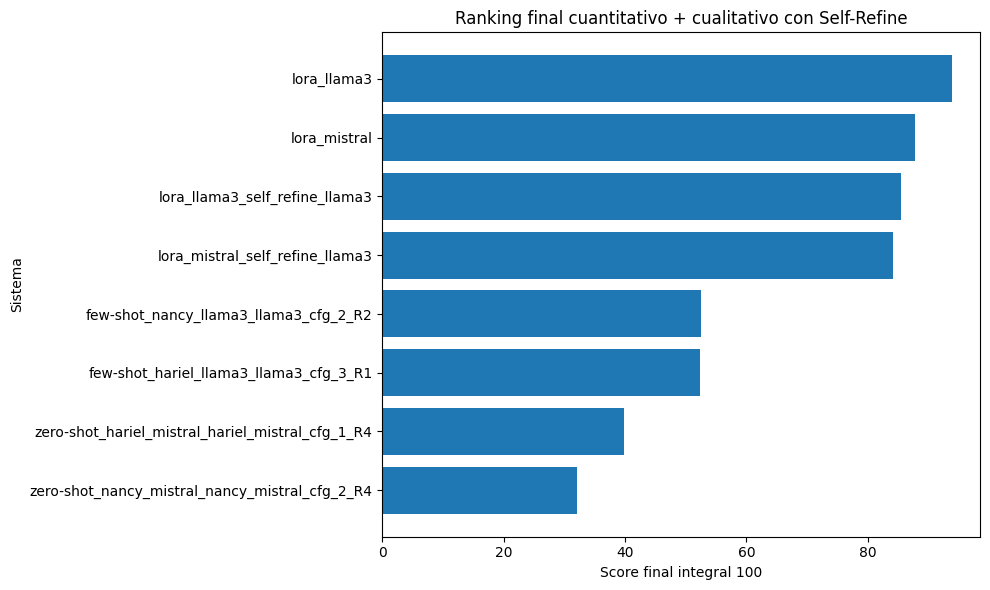

In [28]:
plot_df = final_summary.sort_values("score_final_integral_100", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["system_name"], plot_df["score_final_integral_100"])
plt.xlabel("Score final integral 100")
plt.ylabel("Sistema")
plt.title("Ranking final cuantitativo + cualitativo con Self-Refine")
plt.tight_layout()
plt.show()

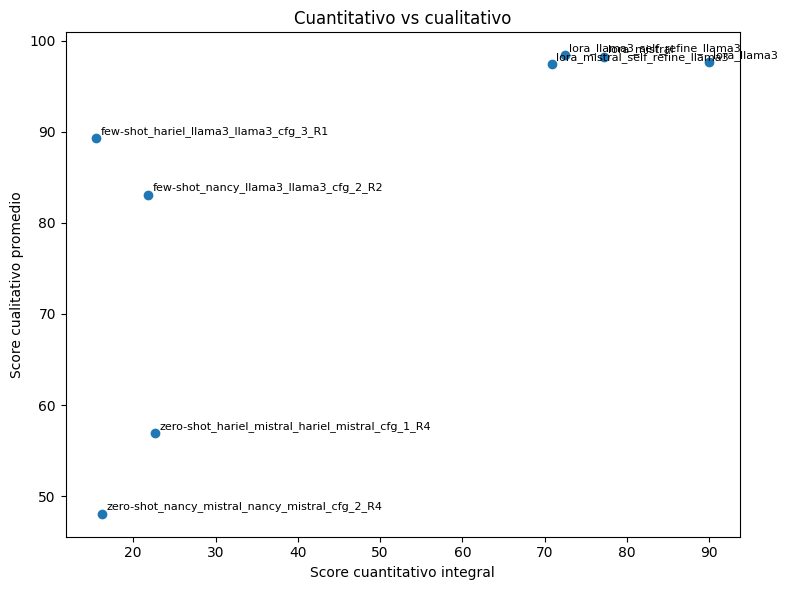

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_summary["score_cuantitativo_integral_100"],
    final_summary["score_cualitativo_promedio_100"],
)

for _, row in final_summary.iterrows():
    plt.text(
        row["score_cuantitativo_integral_100"] + 0.5,
        row["score_cualitativo_promedio_100"] + 0.5,
        row["system_name"],
        fontsize=8,
    )

plt.xlabel("Score cuantitativo integral")
plt.ylabel("Score cualitativo promedio")
plt.title("Cuantitativo vs cualitativo")
plt.tight_layout()
plt.show()

In [30]:
QUAL_DETAIL_PATH = OUT_DIR / "01_detalle_cualitativo_8_sistemas.csv"
QUAL_SUMMARY_PATH = OUT_DIR / "02_resumen_cualitativo_8_sistemas.csv"
QUANT_DETAIL_PATH = OUT_DIR / "03_detalle_cuantitativo_8_sistemas.csv"
QUANT_SUMMARY_PATH = OUT_DIR / "04_resumen_cuantitativo_8_sistemas.csv"
FINAL_SUMMARY_PATH = OUT_DIR / "05_ranking_final_integral_8_sistemas.csv"
DELTA_PATH = OUT_DIR / "06_deltas_lora_base_vs_self_refine.csv"
EXCEL_PATH = OUT_DIR / "evaluacion_final_con_self_refine.xlsx"

qual_detail.to_csv(QUAL_DETAIL_PATH, index=False, encoding="utf-8-sig")
qual_summary.to_csv(QUAL_SUMMARY_PATH, index=False, encoding="utf-8-sig")
quant_detail.to_csv(QUANT_DETAIL_PATH, index=False, encoding="utf-8-sig")
quant_scored.to_csv(QUANT_SUMMARY_PATH, index=False, encoding="utf-8-sig")
final_summary.to_csv(FINAL_SUMMARY_PATH, index=False, encoding="utf-8-sig")
delta_compare.to_csv(DELTA_PATH, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(EXCEL_PATH, engine="openpyxl") as writer:
    final_summary.to_excel(writer, sheet_name="Ranking final", index=False)
    quant_scored.to_excel(writer, sheet_name="Resumen cuantitativo", index=False)
    qual_summary.to_excel(writer, sheet_name="Resumen cualitativo", index=False)
    delta_compare.to_excel(writer, sheet_name="Deltas Self-Refine", index=False)
    quant_detail.to_excel(writer, sheet_name="Detalle cuantitativo", index=False)
    qual_detail.to_excel(writer, sheet_name="Detalle cualitativo", index=False)

print("Archivos guardados:")
print("-", QUAL_DETAIL_PATH)
print("-", QUAL_SUMMARY_PATH)
print("-", QUANT_DETAIL_PATH)
print("-", QUANT_SUMMARY_PATH)
print("-", FINAL_SUMMARY_PATH)
print("-", DELTA_PATH)
print("-", EXCEL_PATH)

Archivos guardados:
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/01_detalle_cualitativo_8_sistemas.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/02_resumen_cualitativo_8_sistemas.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/03_detalle_cuantitativo_8_sistemas.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/04_resumen_cuantitativo_8_sistemas.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/05_ranking_final_integral_8_sistemas.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/06_deltas_lora_base_vs_self_refine.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_final_con_self_refine/evaluacion_final_con_self_refine.xlsx


In [31]:
best = final_summary.iloc[0]

conclusion = f"""
## Conclusión final preliminar

Después de integrar la evaluación cuantitativa y cualitativa de los sistemas originales y las variantes con Self-Refine, el sistema con mejor desempeño global fue:

**{best['system_name']}**

Resultados principales:

- Score final integral: {best['score_final_integral_100']:.2f}
- Score cuantitativo integral: {best['score_cuantitativo_integral_100']:.2f}
- Score cualitativo promedio: {best['score_cualitativo_promedio_100']:.2f}
- Leader score: {best['leader_score']:.2f}
- SARI: {best['sari']:.2f}
- BERTScore F1: {best['bertscore_f1']:.4f}
- Compression ratio: {best['compression_ratio_eval']:.4f}
- Exact copy: {best['exact_copy']:.4f}

La comparación con Self-Refine permite observar si la post-edición mejora la calidad cualitativa y reduce copias exactas, aunque no necesariamente incrementa todas las métricas automáticas.
"""

print(conclusion)


## Conclusión final preliminar

Después de integrar la evaluación cuantitativa y cualitativa de los sistemas originales y las variantes con Self-Refine, el sistema con mejor desempeño global fue:

**lora_llama3**

Resultados principales:

- Score final integral: 93.78
- Score cuantitativo integral: 89.95
- Score cualitativo promedio: 97.61
- Leader score: 63.03
- SARI: 45.34
- BERTScore F1: 0.8957
- Compression ratio: 0.8353
- Exact copy: 0.1389

La comparación con Self-Refine permite observar si la post-edición mejora la calidad cualitativa y reduce copias exactas, aunque no necesariamente incrementa todas las métricas automáticas.

